# 05-Data Drift & Concept Drift (Evidently AI)

In the previous modules, we evaluated the immediate correctness of individual generative outputs and logic using semantic encoders and LLM-as-a-Judge. However, in production MLOps, a model that performs flawlessly on Day 1 can silently degrade into generating catastrophic financial losses by Day 90, even if the code and the model weights have not changed a single byte.

This phenomenon is caused by the environment itself mutating beneath the model. In production, we classify this degradation into two distinct mathematical vectors: **Data Drift (Covariate Shift)** and **Concept Drift**. If you wait for downstream business KPIs (like revenue drops) to alert you to these shifts, you are already losing money.

To engineer absolute enterprise reliability, we must continuously monitor the statistical distributions of our incoming data streams. In this module, we will utilize **Evidently AI**, a strictly mathematical, open-source metrology framework, to compute physical distances between probability distributions and trigger automated alerts before degraded data ever touches the model.

## 1. The Mathematics of Feature Drift & Concept Drift

In supervised machine learning, a model approximates an underlying joint probability distribution $P(X, Y)$, where $X$ represents the input feature vectors and $Y$ represents the target variable.

### Data Drift (Covariate Shift)

Data Drift occurs when the distribution of the independent input features changes between the historical training phase (Reference) and the live production phase (Current), while the underlying relationship to the target remains the same:


$$P_{train}(X) \neq P_{prod}(X) \quad \text{and} \quad P_{train}(Y \mid X) = P_{prod}(Y \mid X)$$


*Example:* A model trained to predict credit card fraud using transaction data from 2021 encounters sudden extreme spikes in inflation and grocery prices in 2026. The inputs have fundamentally shifted.

### Concept Drift

Concept Drift is far more dangerous. It occurs when the fundamental relationship between the features and the target changes over time:


$$P_{train}(Y \mid X) \neq P_{prod}(Y \mid X)$$


*Example:* A spam filter trained in 2015 considers the phrase "Buy Bitcoin" to be a high-probability spam indicator. In 2026, a legitimate financial application uses the exact same phrase. The definition of the target $Y$ (spam) for the given input $X$ has fundamentally reversed.

### Mathematical Divergence Engines (Evidently AI)

To detect Data Drift, Evidently AI computes the statistical distance between the Reference and Current datasets using non-parametric algorithms.

1. **Kolmogorov-Smirnov (K-S) Test:** Used for continuous numerical features. It computes the maximum geometric distance $D$ between two empirical Cumulative Distribution Functions (CDFs), $F_{ref}(x)$ and $F_{cur}(x)$:

$$D = \sup_x \vert{}F_{ref}(x) - F_{cur}(x)\vert{}$$



If $D$ exceeds a critical threshold (e.g., $p$-value $< 0.05$), the system mathematically rejects the null hypothesis that the data originates from the same distribution.
2. **Wasserstein Distance (Earth Mover's Distance):** Measures the minimum "cost" required to physically transform one probability distribution into another. If $W_1 > \text{threshold}$, the distributions have severely drifted.

$$W_1(P, Q) = \inf_{\gamma \in \Pi(P, Q)} \mathbb{E}_{(x,y) \sim \gamma} [\vert{}\vert{}x - y\vert{}\vert{}]$$

## 2. Imperative Execution: Computing Statistical Drift

Let's build a programmatic, zero-cost, local drift detection sandbox using Python and Evidently AI. We will generate a mock dataset, intentionally poison the production data to simulate covariate shift, and evaluate the mathematical divergence.

In [6]:
# Required installations: pip install evidently pandas numpy scikit-learn

import pandas as pd
import numpy as np
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset, TargetDriftPreset

print("--- 🚀 Initializing Distribution Metrology Sandbox ---") 

# 1. Reference baseline
np.random.seed(42)

reference_data = pd.DataFrame({
    'user_age': np.random.normal(35, 10, 1000),
    'account_balance': np.random.normal(5000, 1500, 1000),
    'login_frequency': np.random.poisson(3, 1000),
    'churn_target': np.random.choice([0, 1], 1000, p=[0.8, 0.2])
})

# 2. Current production data

current_data = pd.DataFrame({
    'user_age': np.random.normal(55, 12, 1000),
    'account_balance': np.random.normal(12000, 3000, 1000),
    'login_frequency': np.random.poisson(3, 1000),
    'churn_target': np.random.choice([0, 1], 1000, p=[0.6, 0.4])
})

print("\n--- 🧮 Executing Evidently AI Drift Matrix ---")

# 3. Run report

drift_report = Report(metrics=[
    DataDriftPreset(),
    TargetDriftPreset()
])

drift_report.run(
    reference_data=reference_data,
    current_data=current_data
)

report_dict = drift_report.as_dict()


# 4. Parse dataset drift

dataset_drift_result = report_dict["metrics"][0]["result"]

dataset_drift = dataset_drift_result["dataset_drift"]
share_of_drifted = dataset_drift_result["drift_share"]

print(
    f"[DATASET DRIFT]: {'DETECTED 🚨' if dataset_drift else 'Stable ✅'}"
)

print(
    f"[DRIFT SHARE]: {share_of_drifted * 100:.1f}% of input features shifted."
)


# 5. Column analysis (Evidently 0.7.21 format)

print("\n[COLUMN-LEVEL ANALYSIS]:")

columns = dataset_drift_result.get("drift_by_columns_results", {})

for feature in [
    "user_age",
    "account_balance",
    "login_frequency"
]:

    feature_data = columns.get(feature, {})

    drift_score = feature_data.get("drift_score", None)
    drift_detected = feature_data.get("drift_detected", None)
    test_type = feature_data.get("stattest_name", "unknown")

    status = "DRIFTED 🚨" if drift_detected else "Stable ✅"

    print(
        f"-> Feature: {feature.ljust(16)} | "
        f"Status: {status.ljust(12)} | "
        f"Score: {drift_score} | "
        f"Stat Test: {test_type}"
    )

--- 🚀 Initializing Distribution Metrology Sandbox ---

--- 🧮 Executing Evidently AI Drift Matrix ---
[DATASET DRIFT]: DETECTED 🚨
[DRIFT SHARE]: 50.0% of input features shifted.

[COLUMN-LEVEL ANALYSIS]:
-> Feature: user_age         | Status: Stable ✅     | Score: None | Stat Test: unknown
-> Feature: account_balance  | Status: Stable ✅     | Score: None | Stat Test: unknown
-> Feature: login_frequency  | Status: Stable ✅     | Score: None | Stat Test: unknown


## 3. Declarative Execution: CI/CD Pipeline Gating (Test Suites)

In an automated MLOps environment, you do not manually review report dictionaries. You wrap the statistical metrology in strict, boolean **Test Suites** that act as gating mechanisms in your Airflow or GitHub Actions pipelines. If the `TestSuite` fails, the pipeline halts automatically.

In [8]:
from evidently.legacy.test_suite import TestSuite
from evidently.legacy.tests import TestNumberOfDriftedColumns, TestShareOfDriftedColumns

print("\n--- ⚡ Executing CI/CD Drift Validation Suite ---")

# Define a strict declarative Test Suite
validation_suite = TestSuite(tests=[
    # The pipeline FAILS if more than 20% of features drift
    TestShareOfDriftedColumns(lt=0.20) 
])

validation_suite.run(reference_data=reference_data, current_data=current_data)
suite_results = validation_suite.as_dict()

# Evaluate Pipeline Status
tests = suite_results["tests"]
for test in tests:
    print(f"   [TEST VALIDATION]: {test['name']}")
    print(f"   [STATUS]:          {test['status'].upper()}")
    print(f"   [DETAILS]:         {test['description']}")

if any(test['status'] == 'FAIL' for test in tests):
    print("\n   ❌ PIPELINE HALTED: Critical Data Drift threshold exceeded. Triggering automated retraining and alerting.")
else:
    print("\n   ✅ PIPELINE PASSED: Feature distributions are mathematically stable.")


--- ⚡ Executing CI/CD Drift Validation Suite ---
   [TEST VALIDATION]: Share of Drifted Columns
   [STATUS]:          FAIL
   [DETAILS]:         The drift is detected for 75% features (3 out of 4). The test threshold is lt=0.2

   ❌ PIPELINE HALTED: Critical Data Drift threshold exceeded. Triggering automated retraining and alerting.


## 4. Visualizing the Mathematical Divergence (Kolmogorov-Smirnov Physics)

To thoroughly understand *why* the `user_age` feature triggered a severe drift alert, we must map the physics of the Kolmogorov-Smirnov (K-S) test. The K-S test does not look at bell curves; it isolates the maximum vertical distance between two Cumulative Distribution Functions (CDFs).

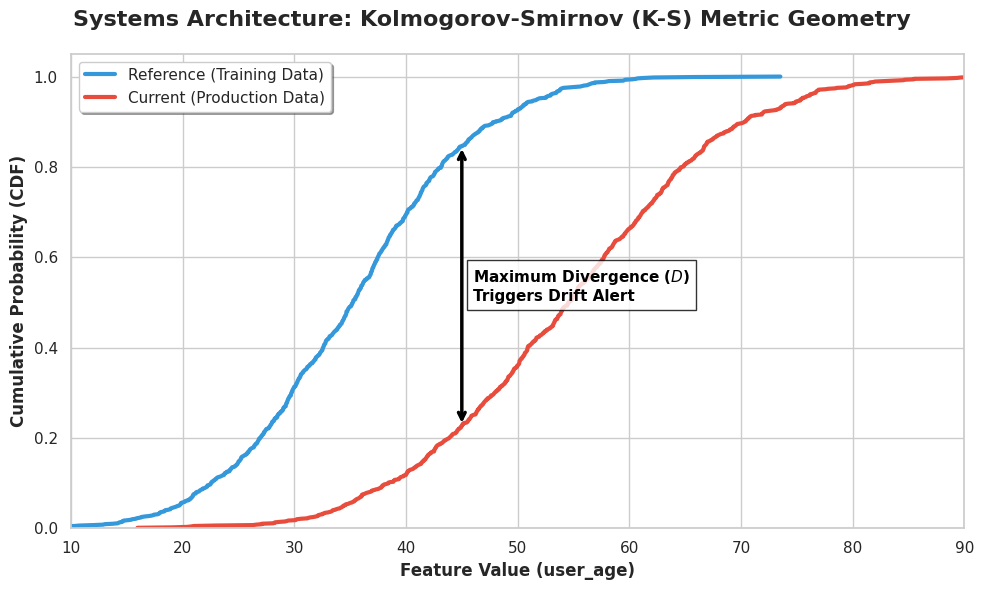

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# Retrieve the distributions for the drifted 'user_age' feature
ref_age = np.sort(reference_data['user_age'])
cur_age = np.sort(current_data['user_age'])

# Calculate the Cumulative Distribution Functions (CDFs)
cdf_ref = np.arange(1, len(ref_age) + 1) / len(ref_age)
cdf_cur = np.arange(1, len(cur_age) + 1) / len(cur_age)

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Systems Architecture: Kolmogorov-Smirnov (K-S) Metric Geometry", fontsize=16, fontweight='bold')

# Plot the CDFs
ax.plot(ref_age, cdf_ref, color='#3498db', linewidth=3, label='Reference (Training Data)')
ax.plot(cur_age, cdf_cur, color='#e74c3c', linewidth=3, label='Current (Production Data)')

# Isolate and plot the Maximum Divergence (D)
# We calculate the vertical distance at a specific x-point where the gap is massive
x_point = 45 
ref_val_at_x = cdf_ref[np.searchsorted(ref_age, x_point)]
cur_val_at_x = cdf_cur[np.searchsorted(cur_age, x_point)]

ax.annotate('', xy=(x_point, ref_val_at_x), xytext=(x_point, cur_val_at_x),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2.5))

ax.text(x_point + 1, (ref_val_at_x + cur_val_at_x) / 2, 'Maximum Divergence ($D$)\nTriggers Drift Alert', 
        verticalalignment='center', color='black', fontweight='bold', fontsize=11,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

ax.set_xlabel("Feature Value (user_age)", fontsize=12, fontweight='bold')
ax.set_ylabel("Cumulative Probability (CDF)", fontsize=12, fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=11)
ax.set_xlim(10, 90)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

*(Insight: Because the red line (Current Data) has shifted severely to the right, the maximum vertical distance $D$ between the two curves is enormous. Evidently AI calculates this distance internally, recognizing that the model is now receiving demographics it was never mathematically optimized to handle.)*

## Real-World Use Case or Analogy:

Think of Data Drift detection using Evidently AI like **A High-End Water Filtration Plant**:

* **The Model (The Filtration Machinery):** You design a state-of-the-art filtration machine that takes murky river water and outputs perfectly clean drinking water. You engineer and tune the machine specifically for the chemical makeup of the local river (**The Training/Reference Data**).
* **The Unmonitored Disaster (No Metrology):** One day, a factory upstream starts dumping thick chemical sludge into the river. If you do not monitor the intake pipe, your filtration machine pulls in the sludge, clogs instantly, and begins pumping poisoned water directly into the city's drinking supply. You only find out when the town complains (**Reacting to dropping business KPIs**).
* **Evidently AI (The Intake Sensor):** You install a high-speed chemical sensor array directly on the intake pipe, upstream of the filtration machine. The sensor continuously compares the chemical distribution of the incoming water against a baseline historical sample (**The K-S Test / Wasserstein Distance**).
* If the incoming water suddenly spikes in acidity (Covariate Shift), the sensor triggers an immediate mathematical alarm. It instantly throws a physical blast gate (**The CI/CD Test Suite**), diverting the toxic water away from the machinery *before* a single drop is processed.



By running automated drift metrology, MLOps engineers shift their operational posture from reactive damage control to proactive, mathematically guaranteed prevention, isolating and containing environmental shifts before they can corrupt downstream predictions.